# **Implementación del caso de 10 Qubits.**

In [2]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
N10 = 261980999226229

## **Implementación con 8 Qubits**

In [4]:
seed = 51

In [5]:
eightQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [6]:
B8, t8 = eightQubit.generate_cvp(10)
print(f'B8 = \n{B8}')
print(f't8 = \n{t8}')

B8 = 
[ 2 0 0 0 0 0 0 0  6931 ]
[ 0 3 0 0 0 0 0 0 10986 ]
[ 0 0 2 0 0 0 0 0 16094 ]
[ 0 0 0 4 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 23979 ]
[ 0 0 0 0 0 3 0 0 25649 ]
[ 0 0 0 0 0 0 1 0 28332 ]
[ 0 0 0 0 0 0 0 4 29444 ]
t8 = 
(0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [7]:
D8, b8_op, res8_vector, sign_step8, w8, dist8 = eightQubit.babai_algorithm(B8, t8, delta = 0.75)
print(f'D8 = \n{D8}\n')
print(f'b8_op = \n{b8_op}\n')
print(f'res8_vector = \n{res8_vector}\n')
print(f'sign_step8 = \n{sign_step8}\n')
print(f'w8 = \n{w8}\n')
print(f'dist8 = \n{dist8}\n')

D8 = 
[  2  0 -4 -4  3  0 -2  4  1 ]
[  0 -3  4  0 -2  3 -1  4  5 ]
[  6 -3  0  0 -4  0  2  4 -1 ]
[  4  0 -2  0 -2  6  1 -4 -4 ]
[ -4  0  6  4 -1  3 -3  4 -3 ]
[  2 -6  6  0  2 -3 -3  4 -2 ]
[  2 -6 -4  4  1 -3  0  4  4 ]
[ -8 -3  0  0 -3  3  3  0 -2 ]

b8_op = 
[     2      0      2      0      0      3     10      0 331994]

res8_vector = 
[ -2   0  -2   0   0  -3 -10   0  -1]

sign_step8 = 
[ 1 -1 -1 -1  1  1  1 -1]

w8 = 
(-8765, 35541, -13511, -8003, -15327, -12503, 6562, -10148)

dist8 = 
10.862780491200215



In [8]:
qubo8 = eightQubit.define_qubo(D8, res8_vector, sign_step8)
print(qubo8.prettyprint())

Hc8, offset8 = eightQubit.define_hamiltonian(qubo8)
print(f'Offset = {offset8}')
print(f'Hamiltonian = {Hc8}')


Problem name: quboProblem

Minimize
  66*z_0^2 - 2*z_0*z_1 - 22*z_0*z_2 + 24*z_0*z_3 - 64*z_0*z_4 + 12*z_0*z_5
  + 54*z_0*z_6 + 66*z_0*z_7 + 80*z_1^2 + 52*z_1*z_2 - 46*z_1*z_3 - 78*z_1*z_4
  - 76*z_1*z_5 - 54*z_1*z_6 + 22*z_1*z_7 + 82*z_2^2 + 44*z_2*z_3 + 14*z_2*z_4
  - 68*z_2*z_5 - 76*z_2*z_6 - 38*z_2*z_7 + 93*z_3^2 + 30*z_3*z_4 + 74*z_3*z_5
  + 72*z_3*z_6 + 6*z_3*z_7 + 112*z_4^2 + 96*z_4*z_5 - 44*z_4*z_6 - 82*z_4*z_7
  + 118*z_5^2 + 70*z_5*z_6 + 36*z_5*z_7 + 114*z_6^2 + 36*z_6*z_7 + 104*z_7^2
  - 46*z_0 - 24*z_1 - 62*z_2 - 56*z_3 - 40*z_4 - 50*z_5 - 18*z_6 - 42*z_7 + 118

Subject to
  No constraints

  Binary variables (8)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7

Offset = 348.0
Hamiltonian = SparsePauliOp(['IIIIIIIZ', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZI', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII'

In [9]:
circuit8 = eightQubit.construct_circuit(Hc8, reps = 1)
print(circuit8.decompose())

     ┌───┐»
q_0: ┤ H ├»
     ├───┤»
q_1: ┤ H ├»
     ├───┤»
q_2: ┤ H ├»
     ├───┤»
q_3: ┤ H ├»
     ├───┤»
q_4: ┤ H ├»
     ├───┤»
q_5: ┤ H ├»
     ├───┤»
q_6: ┤ H ├»
     ├───┤»
q_7: ┤ H ├»
     └───┘»
«     ┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                                                                                                                                                                                                                                                                                                             

In [10]:
x0 = np.asarray([0.0]*circuit8.num_parameters)
optParameters8 = eightQubit.qaoa_algorithm(circuit8, Hc8, x0)

/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [11]:
for param in optParameters8.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = -0.47995403336498355
γ[0] = 0.00844746961840753


In [12]:
results8 = eightQubit.sample_from_parameters(circuit8, optParameters8, shots = 10_000)
print(len(results8))
for bitstring, count in results8.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

219
Bistring: 00000100 -> Counts: 353
Bistring: 00000000 -> Counts: 321
Bistring: 00100110 -> Counts: 305
Bistring: 00010011 -> Counts: 302
Bistring: 00010010 -> Counts: 274
Bistring: 00000010 -> Counts: 272
Bistring: 00000101 -> Counts: 268
Bistring: 00010111 -> Counts: 241
Bistring: 01010110 -> Counts: 225
Bistring: 00001010 -> Counts: 216
Bistring: 10000100 -> Counts: 209
Bistring: 10010010 -> Counts: 202
Bistring: 00100100 -> Counts: 199
Bistring: 11010110 -> Counts: 193
Bistring: 10010100 -> Counts: 189
Bistring: 01010010 -> Counts: 184
Bistring: 00000110 -> Counts: 181
Bistring: 00100010 -> Counts: 181
Bistring: 10010110 -> Counts: 179
Bistring: 01010111 -> Counts: 179
Bistring: 01000100 -> Counts: 164
Bistring: 00100111 -> Counts: 154
Bistring: 00000001 -> Counts: 151
Bistring: 00010110 -> Counts: 149
Bistring: 00010101 -> Counts: 148
Bistring: 01000110 -> Counts: 148
Bistring: 00001000 -> Counts: 121
Bistring: 01100110 -> Counts: 121
Bistring: 00010001 -> Counts: 117
Bistring: 

In [13]:
nD8 = eightQubit.integer_to_matrix(D8)
vnew8 = eightQubit.bitstring2latticeVectors(nD8, results8.keys(), sign_step8, b8_op)
for vect8 in vnew8:
    print(vect8)

[     4     -6      8      0      2      0      7      4 331992]
[     2      0      2      0      0      3     10      0 331994]
[     0     -9      4      4      7     -3      5      4 331997]
[     8     -3      0      4      6     -9      6      8 332004]
[     0     -6      0      4      3     -6      9      8 332002]
[     4     -6     -2      4      1      0     10      4 331998]
[    12     -3      8      0      5     -3      4      4 331994]
[    10     -9      6      4      8    -12      3     12 332002]
[     2     -9      2      4      7    -12      7      8 331995]
[     0     -6      4      8      0      3      7      8 331995]
[     6     -6      4     -4      5      0      5      8 331993]
[     2     -6     -4      0      6     -6      7     12 332003]
[    -2     -3      8      0      6      0      5      0 331993]
[     4     -9     -2      0     10    -12      5     12 331996]
[     2     -6      6     -4      7     -6      4     12 331997]
[     0     -3     -4    

In [14]:
distances8 = eightQubit.get_distances(vnew8, t8)
for dist8 in distances8:
    print(dist8)

13.638181696985855
10.862780491200215
15.0996688705415
20.663978319771825
17.97220075561143
14.628738838327793
16.852299546352718
25.98076211353316
20.37154878746336
15.556349186104045
14.7648230602334
20.518284528683193
11.74734012447073
22.869193252058544
18.788294228055936
16.703293088490067
18.76166303929372
12.569805089976535
25.39685019840059
24.020824298928627
12.884098726725126
18.0
13.416407864998739
23.130067012440755
20.024984394500787
16.673332000533065
13.784048752090222
14.352700094407323
14.933184523068078
22.869193252058544
17.233687939614086
19.519221295943137
14.106735979665885
29.171904291629644
14.071247279470288
22.045407685048602
20.37154878746336
17.663521732655695
16.881943016134134
12.449899597988733
23.600847442411894
11.74734012447073
24.310491562286437
15.198684153570664
20.074859899884732
17.08800749063506
14.7648230602334
18.81488772222678
20.92844953645635
23.302360395462088
21.817424229271428
16.06237840420901
12.165525060596439
18.894443627691185
14.696

In [15]:
nB8 = eightQubit.integer_to_matrix(B8)
uv_pairs8 = eightQubit.vectors2uv_pairs(nB8, vnew8)
print(uv_pairs8)

[[2358421523067500 9]
 [262079207058370 1]
 [91999412213868775 351]
 [1728919862986450288 6591]
 [398862851561440189 1521]
 [11797596305427548 45]
 [10222866833960000 39]
 [202258638561258356000 771147]
 [202067508986541377410 771147]
 [2359006255676525 9]
 [16509929936845400 63]
 [9972162781153990054 38025]
 [1572102054235625 6]
 [1010397475978377635852 3855735]
 [2790906538588792250 10647]
 [43182151876941182567 164775]
 [276029655059820200 1053]
 [7864168981413437 30]
 [46663957325204606420 177957]
 [875886356885280922720 3341637]
 [10213206469368100 39]
 [398782715755454800 1521]
 [262157171406240 1]
 [46661189484009311750 177957]
 [1728115503770150000 6591]
 [1195353685174842424 4563]
 [5764488970638125 22]
 [398405875629322253 1521]
 [44316127725216600 169]
 [12097526083001612000 46137]
 [398677285406778125 1521]
 [122700348004532375 468]
 [23856848758741603 91]
 [202270636107786952640 771147]
 [3407234413495000 13]
 [1196484334246678400 4563]
 [61353813162365185 234]
 [511381255

In [16]:
sr_pairs8 = eightQubit.uv_pairs2sr_pairs(uv_pairs8)
print(sr_pairs8)

[]


In [17]:
probs8 = eightQubit.get_probs(results8, shots = 10_000)

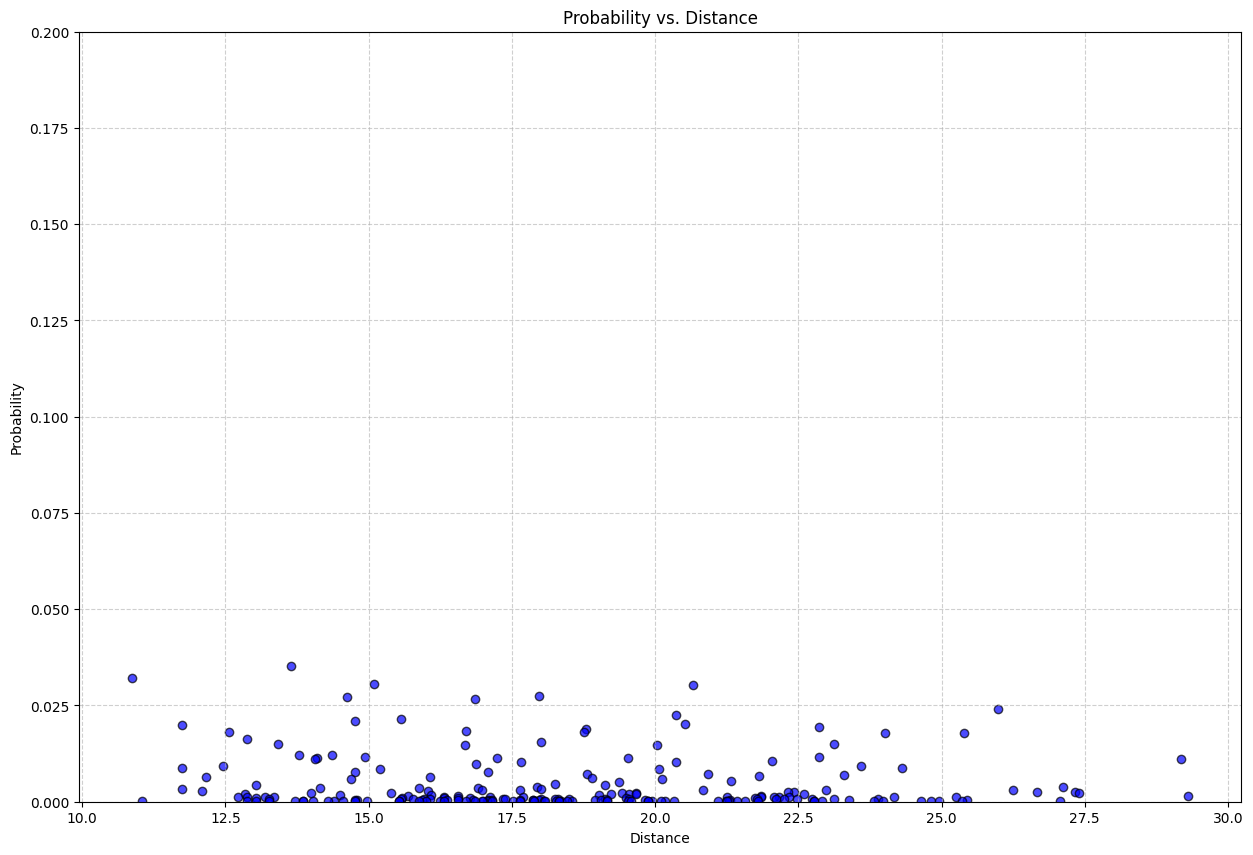

In [18]:
plt.figure(figsize=(15, 10))

# Creating the scatter plot
plt.scatter(distances8, probs8, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.20) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Implementación con 10 Qubits**

In [19]:
seed = 42

In [20]:
tenQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [21]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [22]:
B10, t10 = tenQubit.generate_cvp(10)
print(f'B10 = \n{B10}')
print(f't10 = \n{t10}')

B10 = 
[ 5 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 1 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 4 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 2 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 5 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 3 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 4 33673 ]
t10 = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [23]:
D10, b10_op, res10_vector, sign_step10, w10, dist10 = tenQubit.babai_algorithm(B10, t10, delta = 0.75)
print(f'D10 = \n{D10}\n')
print(f'b10_op = \n{b10_op}\n')
print(f'res10_vector = \n{res10_vector}\n')
print(f'sign_step10 = \n{sign_step10}\n')
print(f'w10 = \n{w10}\n')
print(f'dist10 = \n{dist10}\n')

D10 = 
[  0  1  3 -1  0  2  0  3 -4  0  4 ]
[  5  3 -3  2  0  0  0  0 -4  0  3 ]
[  0  4 -3  1 -4 -2  0  0 -2  4 -1 ]
[  0  4 -3 -1  0  4 -5  0 -2  0  2 ]
[  0  1 -3 -3  0 -2  5  3  2  0 -3 ]
[  0 -1 -6  0  0 -4  0  3  2  4  0 ]
[ -5 -2  3  4  0  0  0  0 -2 -4 -1 ]
[  0  5  0  3  0 -4 -5  0  0 -4  4 ]
[ -5  4  0 -2  0  0  0 -3  2  0  6 ]
[ -5  2  0  1  4  0  0 -3 -4  4 -2 ]

b10_op = 
[     0      1      0      6      0      4      0      6      6      0
 331991]

res10_vector = 
[ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

sign_step10 = 
[ 1  1  1 -1 -1 -1 -1  1  1  1]

w10 = 
(15714, 20489, -11636, -10577, -17862, 19313, 3326, -7285, 28799, -11636)

dist10 = 
11.357816691600547



In [24]:
qubo10 = tenQubit.define_qubo(D10, res10_vector, sign_step10)
print(qubo10.prettyprint())
Hc10, offset10 = tenQubit.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  56*z_0^2 + 40*z_0*z_1 - 12*z_0*z_2 - 40*z_0*z_3 + 40*z_0*z_4 + 52*z_0*z_5
  - 14*z_0*z_6 + 20*z_0*z_7 + 26*z_0*z_8 + 72*z_1^2 + 56*z_1*z_2 - 66*z_1*z_3
  + 22*z_1*z_4 - 14*z_1*z_5 + 54*z_1*z_6 + 66*z_1*z_7 - 14*z_1*z_8 - 14*z_1*z_9
  + 67*z_2^2 - 36*z_2*z_3 - 26*z_2*z_4 - 68*z_2*z_5 + 48*z_2*z_6 + 22*z_2*z_7
  + 8*z_2*z_8 + 38*z_2*z_9 + 75*z_3^2 - 54*z_3*z_4 - 12*z_3*z_5 - 38*z_3*z_6
  - 68*z_3*z_7 - 52*z_3*z_8 - 22*z_3*z_9 + 70*z_4^2 + 76*z_4*z_5 - 48*z_4*z_6
  + 66*z_4*z_7 + 26*z_4*z_8 + 24*z_4*z_9 + 82*z_5^2 - 72*z_5*z_6 + 10*z_5*z_7
  + 18*z_5*z_8 + 6*z_5*z_9 + 75*z_6^2 - 28*z_6*z_7 + 2*z_6*z_8 - 38*z_6*z_9
  + 107*z_7^2 + 76*z_7*z_8 - 22*z_7*z_9 + 94*z_8^2 + 40*z_8*z_9 + 91*z_9^2
  - 22*z_0 - 30*z_1 - 16*z_2 + 4*z_3 - 22*z_4 - 26*z_5 - 24*z_6 - 2*z_7 - 52*z_8
  - 60*z_9 + 129

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 418.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI'

In [25]:
circuit10 = tenQubit.construct_circuit(Hc10, reps= 1)
print(circuit10.decompose(reps = 2))

     ┌────────────┐ ┌────────────────┐                              »
q_0: ┤ U(π/2,0,π) ├─┤ Rz((-90)*γ[0]) ├─■─────────────■──────────────»
     ├────────────┤┌┴────────────────┤ │ZZ(20*γ[0])  │              »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-107)*γ[0]) ├─■─────────────┼──────────────»
     ├────────────┤└┬────────────────┤               │ZZ((-6)*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz((-66)*γ[0]) ├───────────────■──────────────»
     ├────────────┤ └┬──────────────┬┘                              »
q_3: ┤ U(π/2,0,π) ├──┤ Rz(115*γ[0]) ├───────────────────────────────»
     ├────────────┤┌─┴──────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-111)*γ[0]) ├──────────────────────────────»
     ├────────────┤└┬────────────────┤                              »
q_5: ┤ U(π/2,0,π) ├─┤ Rz((-54)*γ[0]) ├──────────────────────────────»
     ├────────────┤ └┬─────────────┬─┘                              »
q_6: ┤ U(π/2,0,π) ├──┤ Rz(16*γ[0]) ├────────────────────────────────»
     ├────────────┤┌

In [26]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
optParameters10 = tenQubit.qaoa_algorithm(circuit10, Hc10, x0)

In [27]:
for param in optParameters10.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = -0.5089978305652973
γ[0] = 0.008621521415162203


In [28]:
results10 = tenQubit.sample_from_parameters(circuit10, optParameters10, shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

582
Bistring: 1001001000 -> Counts: 214
Bistring: 0000000000 -> Counts: 201
Bistring: 1001101000 -> Counts: 195
Bistring: 0001101000 -> Counts: 190
Bistring: 0000001000 -> Counts: 190
Bistring: 0001001000 -> Counts: 175
Bistring: 0001101100 -> Counts: 174
Bistring: 0001011000 -> Counts: 159
Bistring: 1001001001 -> Counts: 154
Bistring: 1001011000 -> Counts: 149
Bistring: 1000001000 -> Counts: 147
Bistring: 1011001000 -> Counts: 142
Bistring: 0000001100 -> Counts: 138
Bistring: 1000001010 -> Counts: 129
Bistring: 0000001001 -> Counts: 124
Bistring: 0000001010 -> Counts: 121
Bistring: 0001001001 -> Counts: 119
Bistring: 0001000000 -> Counts: 114
Bistring: 0000101100 -> Counts: 114
Bistring: 1000000000 -> Counts: 108
Bistring: 1001101100 -> Counts: 106
Bistring: 1001101010 -> Counts: 102
Bistring: 0001100000 -> Counts: 98
Bistring: 0011001000 -> Counts: 95
Bistring: 0001111100 -> Counts: 94
Bistring: 0000011000 -> Counts: 89
Bistring: 0000100100 -> Counts: 89
Bistring: 1001000000 -> Count

In [29]:
nD10 = tenQubit.integer_to_matrix(D10)
vnew10 = tenQubit.bitstring2latticeVectors(nD10, results10.keys(), sign_step10, b10_op)
for vect10 in vnew10:
    print(vect10)

[     5      0      3      2      0      2      5      9      6      4
 331994]
[     0      1      0      6      0      4      0      6      6      0
 331991]
[     5     -1      6      5      0      4      0      6      4      4
 331997]
[     5     -2      3      6      0      2      0      3      8      4
 331993]
[     5      3     -3      2      0      4      0      6      8      4
 331992]
[     5     -1      0      3      0      0      5      6     10      4
 331990]
[     5      3      3      9      0     -2     -5      3      8      0
 331997]
[     5      0      6      3      0      4      5      3      8      0
 331990]
[     0      2      3      3      4      2      5      6      2      8
 331992]
[     5      1      9      2      0      6      5      6      4      0
 331994]
[     5      4      0      1      0      6      0      9      4      4
 331996]
[     5      4      0      3     -4      0      5      9      4      8
 331993]
[     5      8     -3      5      0     

In [30]:
distances10 = tenQubit.get_distances(vnew10, t10)
for dist10 in distances10:
    print(dist10)

14.177446878757825
11.357816691600547
13.674794331177344
12.922847983320086
13.416407864998739
14.866068747318506
15.556349186104045
13.892443989449804
13.114877048604
15.0
14.142135623730951
15.874507866387544
16.0312195418814
16.431676725154983
13.152946437965905
14.966629547095765
13.856406460551018
14.422205101855956
17.97220075561143
12.767145334803704
16.792855623746664
15.198684153570664
14.212670403551895
16.852299546352718
17.320508075688775
12.806248474865697
18.65475810617763
14.212670403551895
15.84297951775486
16.61324772583615
14.560219778561036
13.892443989449804
14.560219778561036
17.4928556845359
14.798648586948742
15.362291495737216
15.84297951775486
15.165750888103101
15.0996688705415
16.703293088490067
13.416407864998739
14.2828568570857
12.649110640673518
14.594519519326424
15.297058540778355
16.15549442140351
14.798648586948742
18.973665961010276
14.45683229480096
13.30413469565007
14.66287829861518
13.490737563232042
20.46948949045872
16.941074346097416
15.811388

In [31]:
nB10 = tenQubit.integer_to_matrix(B10)
uv_pairs10 = tenQubit.vectors2uv_pairs(nB10, vnew10)
for pair10 in uv_pairs10:
    print(pair10)

[262078058335730 1]
[261991323844341 1]
[786516396634150 3]
[2358275479138670 9]
[1310065736807646 5]
[785809757098954 3]
[57931005868178310 221]
[261977923439050 1]
[262012871275155 1]
[262119418401750 1]
[262154661348762 1]
[2882508035594922 11]
[22279671311401854 85]
[1836068173280991 7]
[1309739882231781 5]
[1310769316687779 5]
[261871433827773 1]
[7071698751104155 27]
[75778073514523926 289]
[262132826044635 1]
[4458638042784450 17]
[262312933571325 1]
[21222711489550025 81]
[187261881680842038 715]
[129251100049139250 493]
[262054497183570 1]
[2197381093096279545 8381]
[2358506064707975 9]
[1310178082724532 5]
[6552805178814804 25]
[7600277737807650 29]
[262089455234607 1]
[2883542722375770 11]
[6556324408234146 25]
[262218809172645 1]
[7078057977206125 27]
[129242486897948970 493]
[44284284952292574 169]
[22274129656016469 85]
[72044852542903422 275]
[4455822364931574 17]
[2881986154104582 11]
[523852316714727 2]
[262077260557707 1]
[129211330479893361 493]
[261981005921397 1]
[

In [32]:
sr_pairs10 = tenQubit.uv_pairs2sr_pairs(uv_pairs10)
print(sr_pairs10)

[]


In [33]:
probs10 = tenQubit.get_probs(results10, shots = 10_000)

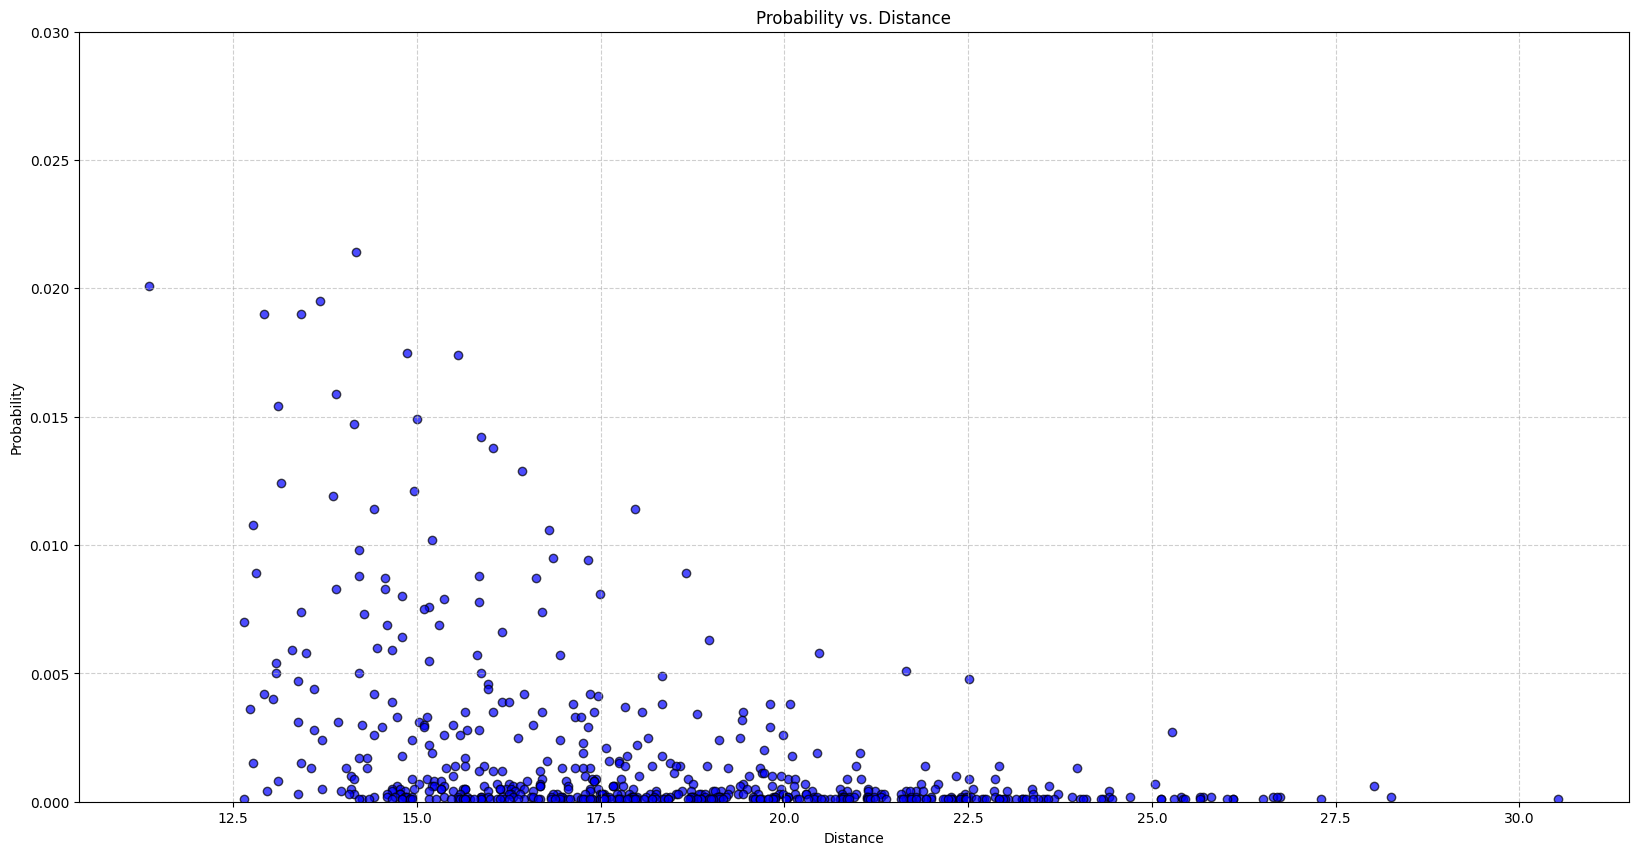

In [34]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.03) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()